In [1]:
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt

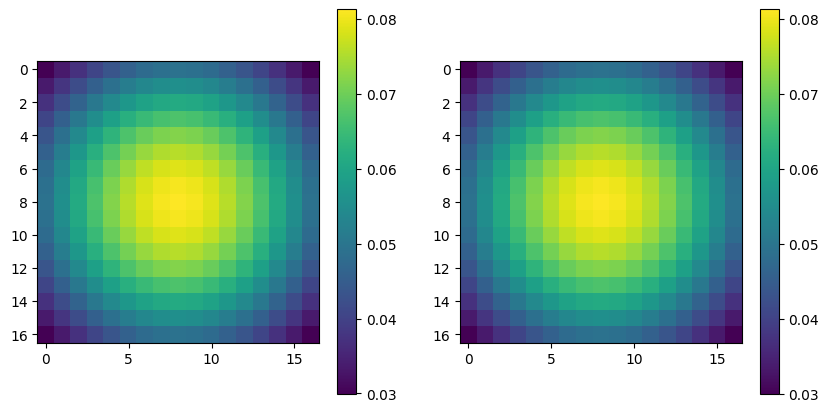

In [2]:
xs = jnp.linspace(-1, 1, 17)
ys = jnp.linspace(-1, 1, 17)
h = xs[1] - xs[0]
X, Y = jnp.meshgrid(xs, ys)

window1 = jsp.stats.multivariate_normal.pdf(jnp.stack([X, Y], axis=-1), jnp.zeros(2), jnp.eye(2)) 
window1 = window1 / jnp.linalg.norm(window1)
window2 = jsp.stats.norm.pdf(xs, 0, 1) * jsp.stats.norm.pdf(ys[:, None], 0, 1)
window2 = window2 / jnp.linalg.norm(window2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
im1 = axs[0].imshow(window1)
im2 = axs[1].imshow(window2)
fig.colorbar(im1, ax=axs[0])
fig.colorbar(im2, ax=axs[1])
plt.show()

Energy of dW: 10240.8173828125
Energy of dW_covolved1: 7452.521484375
Energy of dW_covolved2: 7452.521484375


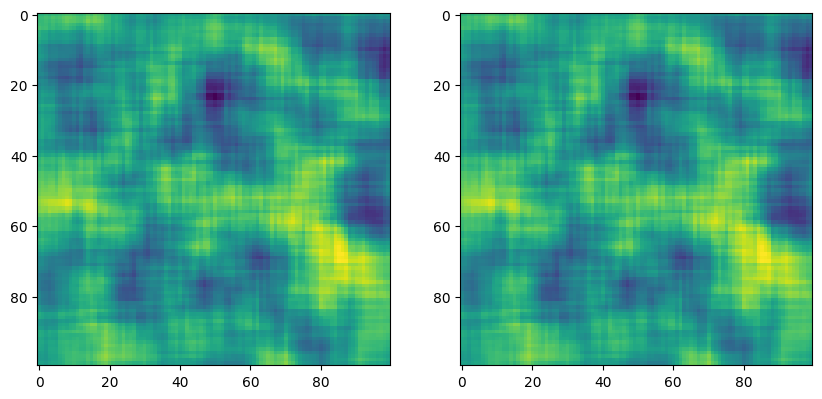

In [3]:
import jax.random as jr

rng = jr.PRNGKey(0)

dW = jr.normal(rng, (100, 100))
print(f"Energy of dW: {jnp.sum(dW**2)}")

dW_covolved1 = jsp.signal.convolve(dW, window1, mode="same") 
dW_covolved2 = jsp.signal.convolve(dW, window2, mode="same") 

print(f"Energy of dW_covolved1: {jnp.sum(dW_covolved1**2)}")
print(f"Energy of dW_covolved2: {jnp.sum(dW_covolved2**2)}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(dW_covolved1)
axs[1].imshow(dW_covolved2)
plt.show()

Variance of dW: 1.0240750312805176
Variance of dW_convolved_fft: 1.0119316577911377


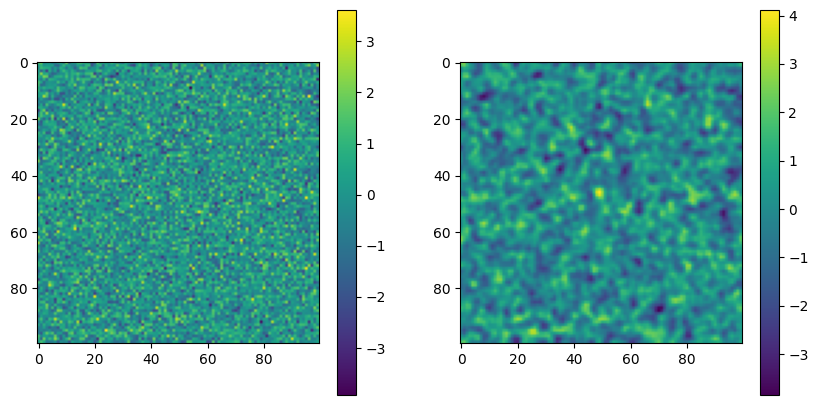

In [11]:
x = jnp.fft.fftfreq(100)
xx, yy = jnp.meshgrid(x, x, indexing="ij")
kernel_ft = jnp.exp(-2. * jnp.pi**2 * (xx**2 + yy**2))
kernel_ft = kernel_ft / jnp.sqrt(jnp.sum(jnp.abs(kernel_ft)**2) / kernel_ft.size)

dW_convolved_fft = jnp.fft.ifft2(kernel_ft * jnp.fft.fft2(dW)).real

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
im1 = axs[0].imshow(dW)
im2 = axs[1].imshow(dW_convolved_fft)
fig.colorbar(im1, ax=axs[0])
fig.colorbar(im2, ax=axs[1])

print(f"Variance of dW: {jnp.var(dW)}")
print(f"Variance of dW_convolved_fft: {jnp.var(dW_convolved_fft)}")
plt.show()